In [2]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv("superstore_final_dataset.csv", encoding="latin1")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Dispaly the dataset
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [4]:
# Dataset Size
df.shape

(9800, 18)

In [5]:
# Columns Name 
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='str')

In [6]:
# Datset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## #Data Cleaning

## 1.Null Checking

In [7]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


In [8]:
df['Postal_Code'].dtype

dtype('float64')

In [9]:
df['Postal_Code']=df['Postal_Code'].fillna("Unknown")

In [10]:
# Create a missing-value summary
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)

missing_summary

,Missing Values,Missing %
Row_ID,0,0.0
Order_ID,0,0.0
Order_Date,0,0.0
Ship_Date,0,0.0
Ship_Mode,0,0.0
Customer_ID,0,0.0
Customer_Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [11]:
df['Postal_Code'].isnull().sum()

np.int64(0)

In [12]:
df.isnull().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

## 2. Lower case Conversion and Space Removing

In [13]:
df.columns= df.columns.str.lower()
df.columns= df.columns.str.replace(' ','_')

In [14]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales'],
      dtype='str')

## 3. Check Duplicate Records

In [15]:
# Check duplicate rows
duplicated_count = df.duplicated().sum()
print("Number of duplicate rows: ",duplicated_count)

Number of duplicate rows:  0


## 4. Describe 

In [16]:
df.describe()

,row_id,sales
count,9800.000000,9800.000000
mean,4900.500000,230.769059
std,2829.160653,626.651875
min,1.000000,0.444000
25%,2450.750000,17.248000
50%,4900.500000,54.490000
75%,7350.250000,210.605000
max,9800.000000,22638.480000


## 5. Check Date Columns

In [17]:
df[['order_date', 'ship_date']].dtypes

order_date    str
ship_date     str
dtype: object

In [18]:
# Convert date columns to datetime
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

In [19]:
df[['order_date', 'ship_date']].dtypes

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object

## 6. Check Numerical Columns

In [20]:
# Statistical summary of numerical columns
df[['sales']].describe()

,sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


## 7. Check Unique Values 

In [21]:
categorical_columns = [
    'ship_mode',
    'segment',
    'country',
    'region',
    'category',
    'sub_category'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


ship_mode:
<ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

segment:
<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

country:
<ArrowStringArray>
['United States']
Length: 1, dtype: str

region:
<ArrowStringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str

category:
<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str

sub_category:
<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str


## 8.Check Invalid Dates

In [22]:
print("Invalid order dates:", df['order_date'].isna().sum())
print("Invalid ship dates:", df['ship_date'].isna().sum())

Invalid order dates: 0
Invalid ship dates: 0


## # Feature Engineering

## 1. Create Year

In [23]:
# Create Year
df['year'] = df['order_date'].dt.year

df[['order_date', 'year']].head()

,order_date,year
0,2017-11-08,2017
1,2017-11-08,2017
2,2017-06-12,2017
3,2016-10-11,2016
4,2016-10-11,2016


## 2. Create Month

In [24]:
# Create Month Name
df['month'] = df['order_date'].dt.month_name()

# Create Month Number
df['month_number'] = df['order_date'].dt.month

df[['order_date', 'month', 'month_number']].head()

,order_date,month,month_number
0,2017-11-08,November,11
1,2017-11-08,November,11
2,2017-06-12,June,6
3,2016-10-11,October,10
4,2016-10-11,October,10


## 3. Create Quarter

In [25]:
# Create Quarter
df['quarter'] = df['order_date'].dt.quarter

df[['order_date', 'quarter']].head()

,order_date,quarter
0,2017-11-08,4
1,2017-11-08,4
2,2017-06-12,2
3,2016-10-11,4
4,2016-10-11,4


## 4. Create Year-Quarter

In [26]:
# Create Year-Quarter
df['year_quarter'] = (
    df['order_date'].dt.year.astype(str)
    + '-Q'
    + df['order_date'].dt.quarter.astype(str)
)

df[['order_date', 'year_quarter']].head()

,order_date,year_quarter
0,2017-11-08,2017-Q4
1,2017-11-08,2017-Q4
2,2017-06-12,2017-Q2
3,2016-10-11,2016-Q4
4,2016-10-11,2016-Q4


## 5. Create Year-Month

In [27]:
# Create Year-Month
df['year_month'] = df['order_date'].dt.to_period('M').astype(str)

df[['order_date', 'year_month']].head()

,order_date,year_month
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


## 6.Create Shipping Date

In [28]:
# Calculate shipping duration
df['shipping_days'] = (
    df['ship_date'] - df['order_date']
).dt.days

df[['order_date', 'ship_date', 'shipping_days']].head()

,order_date,ship_date,shipping_days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [29]:
df['shipping_days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64

## 7. Create Order-Level Sales

In [30]:
# Calculate total sales per order
order_sales = df.groupby('order_id')['sales'].transform('sum')

df['order_total_sales'] = order_sales

df[['order_id', 'sales', 'order_total_sales']].head()

,order_id,sales,order_total_sales
0,CA-2017-152156,261.9600,993.9000
1,CA-2017-152156,731.9400,993.9000
2,CA-2017-138688,14.6200,14.6200
3,US-2016-108966,957.5775,979.9455
4,US-2016-108966,22.3680,979.9455


## 8. Calculate Customer Total Sales

In [31]:
# Calculate total sales per customer
df['customer_total_sales'] = (
    df.groupby('customer_id')['sales'].transform('sum')
)

df[['customer_id', 'sales', 'customer_total_sales']].head()

,customer_id,sales,customer_total_sales
0,CG-12520,261.9600,1148.7800
1,CG-12520,731.9400,1148.7800
2,DV-13045,14.6200,1119.4830
3,SO-20335,957.5775,2602.5755
4,SO-20335,22.3680,2602.5755


## 9. Create Sales Category

In [32]:
# Create Sales Category
df['sales_category'] = pd.cut(
    df['sales'],
    bins=[0, 100, 500, 1000, float('inf')],
    labels=['Low', 'Medium', 'High', 'Very High']
)

df[['sales', 'sales_category']].head()

,sales,sales_category
0,261.9600,Medium
1,731.9400,High
2,14.6200,Low
3,957.5775,High
4,22.3680,Low


## 10. Create Shipping Speed Category

In [33]:
# Create shipping speed category
df['shipping_category'] = pd.cut(
    df['shipping_days'],
    bins=[-1, 2, 4, 6, float('inf')],
    labels=['Fast', 'Standard', 'Slow', 'Very Slow']
)

df[['shipping_days', 'shipping_category']].head()

,shipping_days,shipping_category
0,3,Standard
1,3,Standard
2,4,Standard
3,7,Very Slow
4,7,Very Slow


## 11 💰 Calculate Average Order Value

In [34]:
# Calculate Average Order Value
total_sales = df['sales'].sum()
total_orders = df['order_id'].nunique()

aov = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(aov, 2))

Total Sales: 2261536.78
Total Orders: 4922
Average Order Value: 459.48


## 12 👥 Calculate Customer-Level Order Frequency

In [35]:
# Number of orders per customer
customer_order_count = (
    df.groupby('customer_id')['order_id']
    .nunique()
)

customer_order_count.head()

customer_id
AA-10315    5
AA-10375    9
AA-10480    4
AA-10645    6
AB-10015    3
Name: order_id, dtype: int64

## 13. Check the New Features

In [36]:
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'year', 'month', 'month_number', 'quarter', 'year_quarter', 'year_month', 'shipping_days', 'order_total_sales', 'customer_total_sales', 'sales_category', 'shipping_category']


In [37]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'year', 'month', 'month_number', 'quarter',
       'year_quarter', 'year_month', 'shipping_days', 'order_total_sales',
       'customer_total_sales', 'sales_category', 'shipping_category'],
      dtype='str')

## 14. Profit 

In [38]:
# Create profit column using 10% profit margin
df['profit'] = df['sales'] * 0.10

# Check
df[['sales', 'profit']].head()

,sales,profit
0,261.9600,26.19600
1,731.9400,73.19400
2,14.6200,1.46200
3,957.5775,95.75775
4,22.3680,2.23680


## # EDA

## 1 💰 Overall KPI Analysis

In [39]:
# Overall Sales KPIs

total_sales = df['sales'].sum()
total_orders = df['order_id'].nunique()
total_customers = df['customer_id'].nunique()
total_products = df['product_id'].nunique()

average_order_value = total_sales / total_orders

print("📊 SALES PERFORMANCE KPIs")
print("-" * 40)
print("Total Sales       :", round(total_sales, 2))
print("Total Orders      :", total_orders)
print("Total Customers   :", total_customers)
print("Total Products    :", total_products)
print("Average Order Value:", round(average_order_value, 2))

📊 SALES PERFORMANCE KPIs
----------------------------------------
Total Sales       : 2261536.78
Total Orders      : 4922
Total Customers   : 793
Total Products    : 1861
Average Order Value: 459.48


## 2 📈 Sales by Year

In [40]:
# Year-wise Sales

yearly_sales = (
    df.groupby('year')['sales']
    .sum()
    .reset_index()
)

yearly_sales

,year,sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


## Visualisation

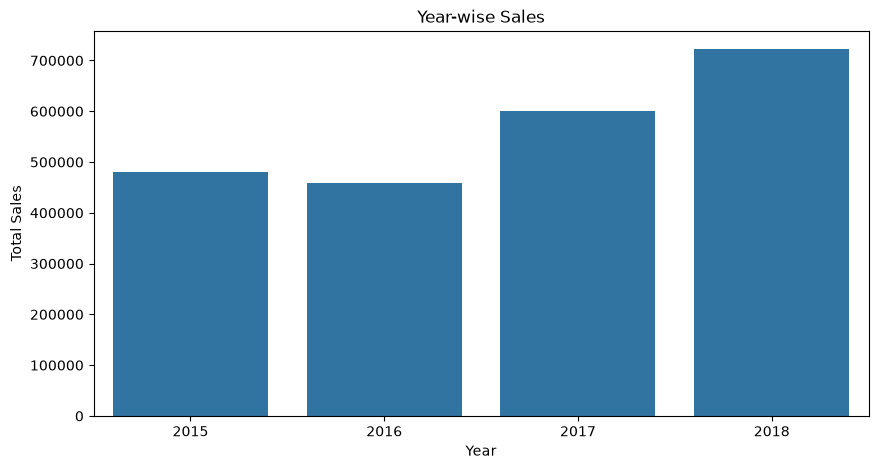

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=yearly_sales,
    x='year',
    y='sales'
)

plt.title('Year-wise Sales')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.show()

## 3 📅 Monthly Sales Trend

In [42]:
# Monthly Sales Trend

monthly_sales = (
    df.groupby('year_month')['sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,year_month,sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


## Visualisation

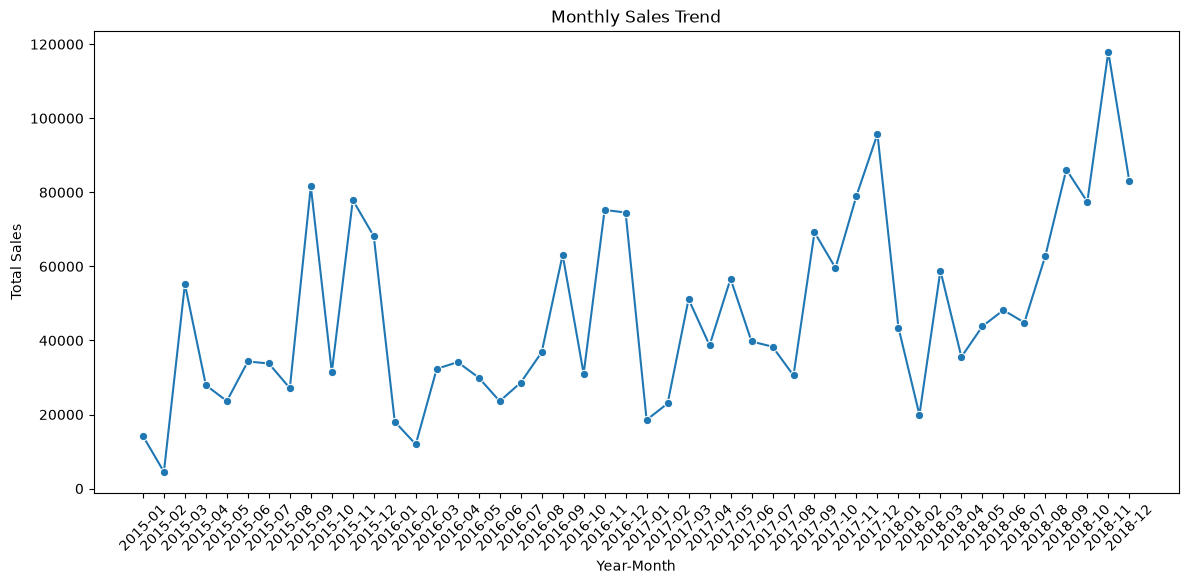

In [43]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x='year_month',
    y='sales',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

## 4 🗓️ Quarterly Sales

In [44]:
# Quarterly Sales

quarterly_sales = (
    df.groupby('year_quarter')['sales']
    .sum()
    .reset_index()
)

quarterly_sales

,year_quarter,sales
0,2015-Q1,73931.3960
1,2015-Q2,85874.0936
2,2015-Q3,142522.6063
3,2015-Q4,177528.1122
4,2016-Q1,62357.6870
5,2016-Q2,87713.3730
6,2016-Q3,128560.2072
7,2016-Q4,180804.7382
8,2017-Q1,92686.3650
9,2017-Q2,135061.1610


## Visualisation

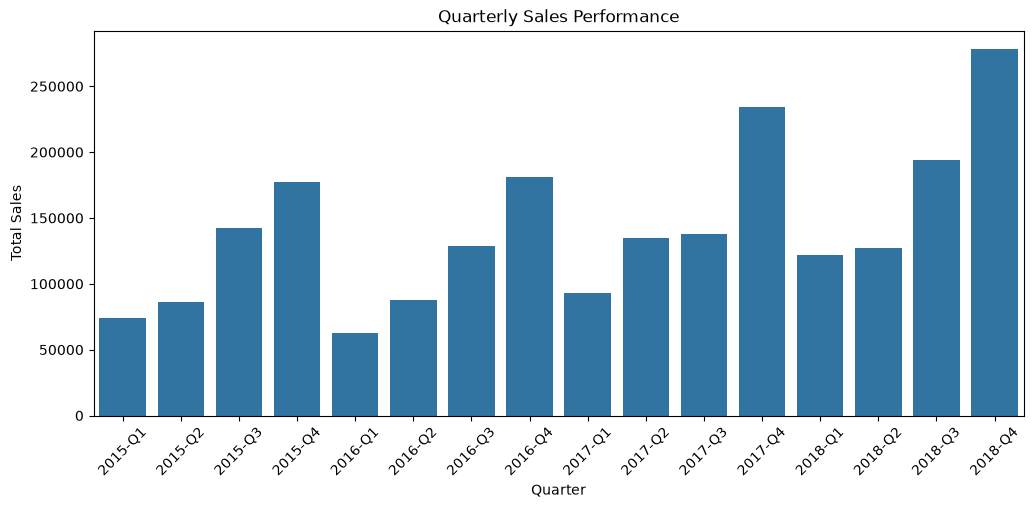

In [45]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=quarterly_sales,
    x='year_quarter',
    y='sales'
)

plt.title('Quarterly Sales Performance')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.show()

## 5 🌎 Regional Sales Analysis

In [46]:
# Region-wise Sales

region_sales = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region_sales

,region,sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


## Visualisation

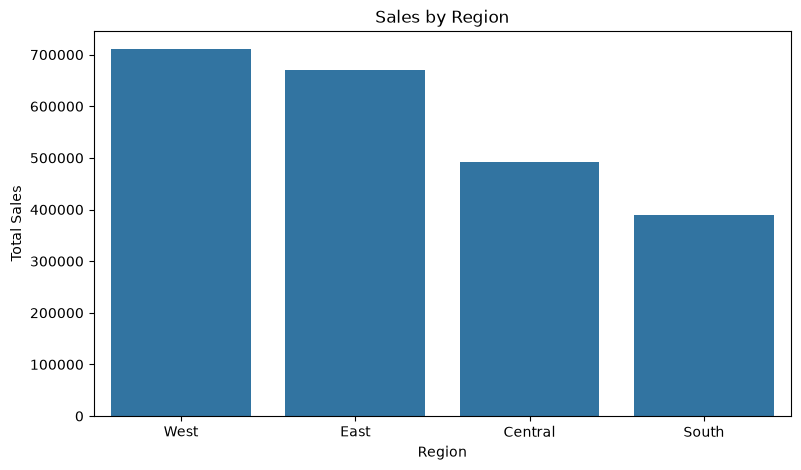

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_sales,
    x='region',
    y='sales'
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.show()

## 6 🏷️ Category Analysis

In [48]:
# Category-wise Sales

category_sales = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,category,sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


## Visualisation

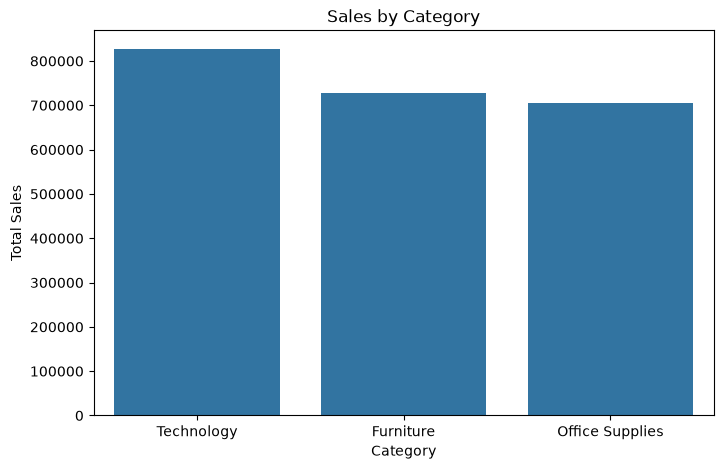

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_sales,
    x='category',
    y='sales'
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

## 7 📦 Sub-Category Analysis

In [50]:
# Sub-category Sales

subcategory_sales = (
    df.groupby('sub_category')['sales']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

subcategory_sales

,sub_category,sales
0,Phones,327782.4480
1,Chairs,322822.7310
2,Storage,219343.3920
3,Tables,202810.6280
4,Binders,200028.7850
5,Machines,189238.6310
6,Accessories,164186.7000
7,Copiers,146248.0940
8,Bookcases,113813.1987
9,Appliances,104618.4030


## Visualisation

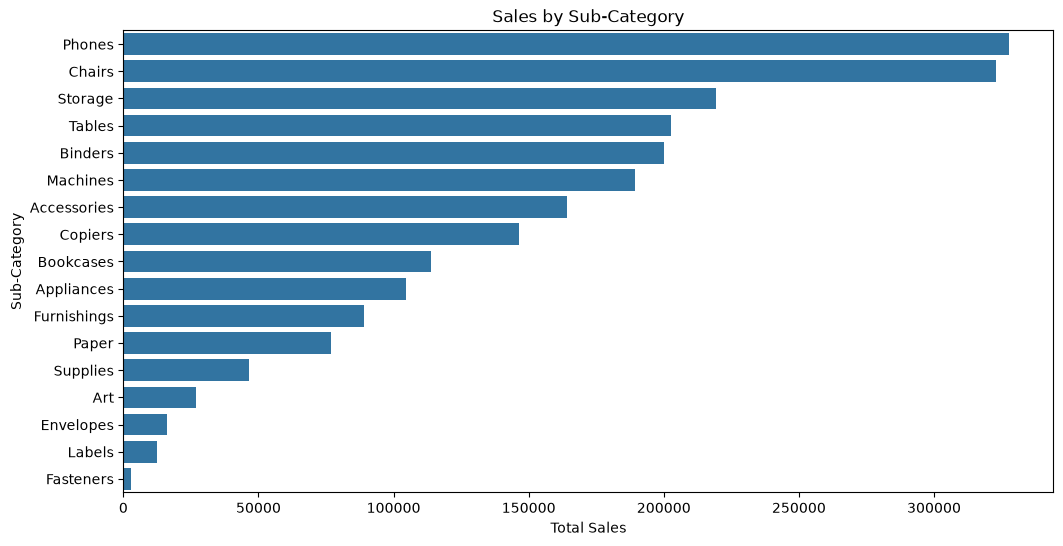

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=subcategory_sales,
    x='sales',
    y='sub_category'
)

plt.title('Sales by Sub-Category')
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')

plt.show()

## 8 🏆 Top 10 Products

In [52]:
# Top 10 Products by Sales

top_products = (
    df.groupby(['product_id', 'product_name'])['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products

,product_id,product_name,sales
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,61599.824
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,19823.479
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,18839.686
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,17965.068
9,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,17030.312


## Visualisation

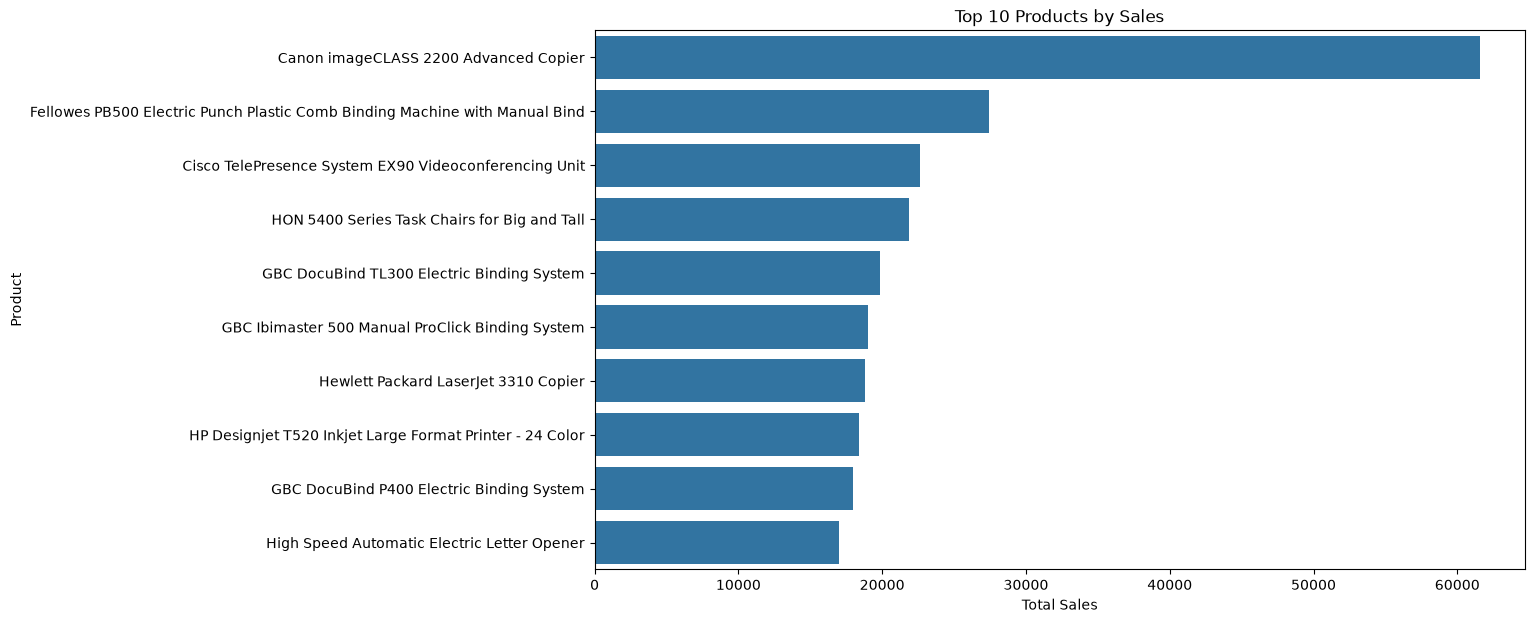

In [53]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x='sales',
    y='product_name'
)

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.show()

## 9 👥 Customer Analysis

In [54]:
# Top 10 Customers by Sales

top_customers = (
    df.groupby(['customer_id', 'customer_name'])['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_customers

,customer_id,customer_name,sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
5,KL-16645,Ken Lonsdale,14175.229
6,SC-20095,Sanjit Chand,14142.334
7,HL-15040,Hunter Lopez,12873.298
8,SE-20110,Sanjit Engle,12209.438
9,CC-12370,Christopher Conant,12129.072


## Visualisation

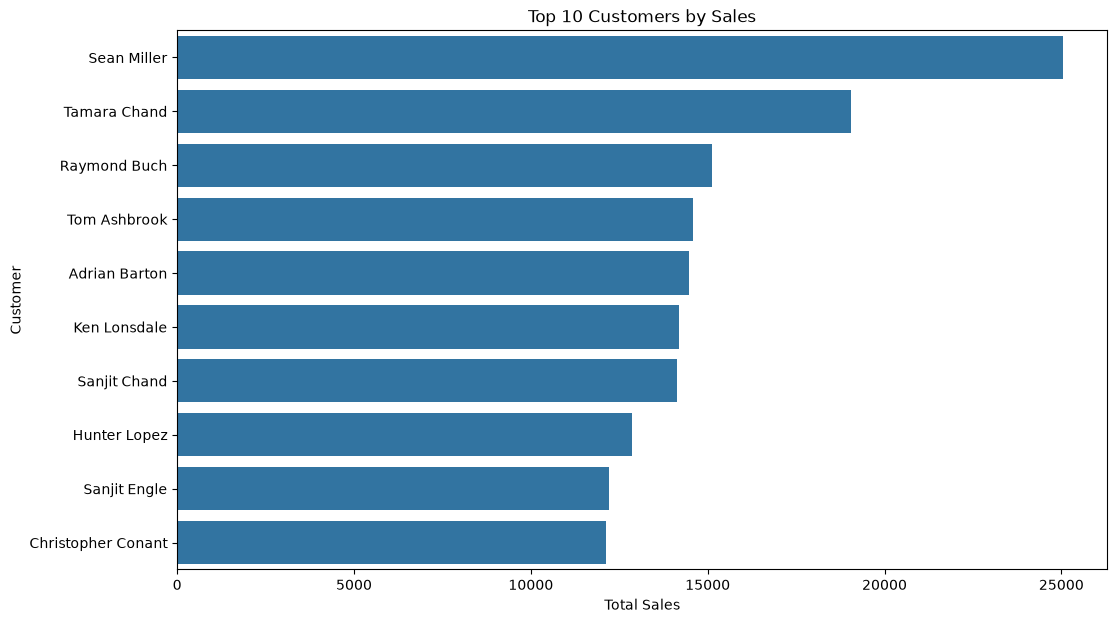

In [55]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_customers,
    x='sales',
    y='customer_name'
)

plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer')

plt.show()

## 10 🚚 Shipping Analysis

In [56]:
shipping_analysis = (
    df.groupby('ship_mode')['shipping_days']
    .agg(['mean', 'min', 'max'])
    .reset_index()
)

shipping_analysis

,ship_mode,mean,min,max
0,First Class,2.179214,1,4
1,Same Day,0.044610,0,1
2,Second Class,3.249211,1,5
3,Standard Class,5.008363,3,7


## Visualisation

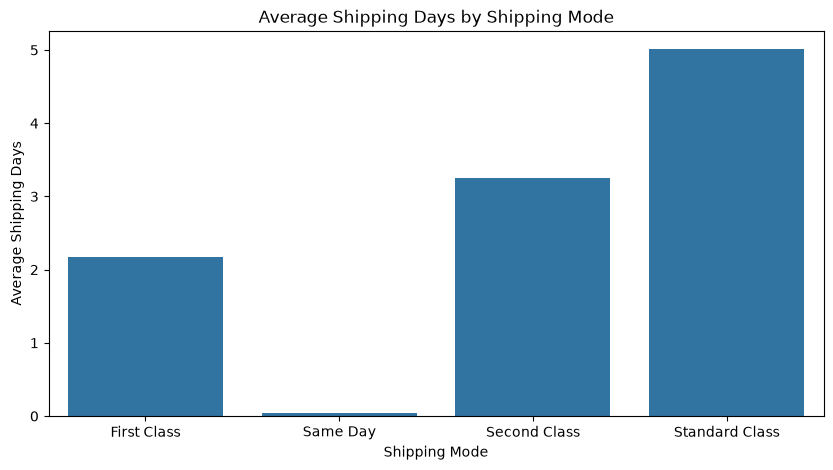

In [57]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=shipping_analysis,
    x='ship_mode',
    y='mean'
)

plt.title('Average Shipping Days by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Average Shipping Days')

plt.show()

## # Advanced Sales Analysis

## 📊  4.1 — Region × Category Sales Analysis

# 1. Create Region × Category Summary

In [58]:
# Region-wise and Category-wise Sales
region_category_sales = (
    df.groupby(['region', 'category'])['sales']
      .sum()
      .reset_index()
      .sort_values('sales', ascending=False)
)

region_category_sales

,region,category,sales
5,East,Technology,263116.5270
11,West,Technology,247404.9300
9,West,Furniture,245348.2455
10,West,Office Supplies,217466.5090
3,East,Furniture,206461.3880
4,East,Office Supplies,199940.8110
2,Central,Technology,168739.2080
1,Central,Office Supplies,163590.2430
0,Central,Furniture,160317.4622
8,South,Technology,148195.2080


# 2. Create a Pivot Table

In [59]:
# Region × Category Sales Pivot
region_category_pivot = pd.pivot_table(
    df,
    values='sales',
    index='region',
    columns='category',
    aggfunc='sum'
)

region_category_pivot

category,Furniture,Office Supplies,Technology
region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


# 3. 📊 Visualize Region × Category

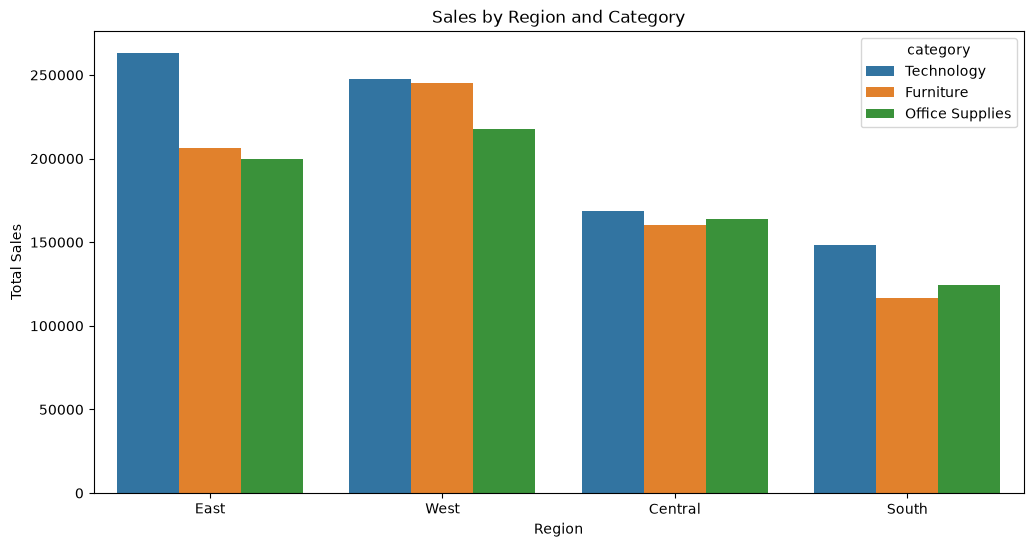

In [60]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_category_sales,
    x='region',
    y='sales',
    hue='category'
)

plt.title('Sales by Region and Category')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.show()

# 4. 🏆 Find the Best Category in Each Region

In [61]:
# Find highest-selling category in each region

top_category_region = (
    region_category_sales
    .sort_values(['region', 'sales'], ascending=[True, False])
    .groupby('region')
    .first()
    .reset_index()
)

top_category_region

,region,category,sales
0,Central,Technology,168739.208
1,East,Technology,263116.527
2,South,Technology,148195.208
3,West,Technology,247404.930


# 5. 📈 Calculate Category Contribution Within Each Region

In [62]:
# Calculate category contribution within each region

region_category_sales['region_total_sales'] = (
    region_category_sales
    .groupby('region')['sales']
    .transform('sum')
)

region_category_sales['sales_contribution_pct'] = (
    region_category_sales['sales']
    / region_category_sales['region_total_sales']
    * 100
)

region_category_sales

,region,category,sales,region_total_sales,sales_contribution_pct
5,East,Technology,263116.5270,669518.7260,39.299353
11,West,Technology,247404.9300,710219.6845,34.834986
9,West,Furniture,245348.2455,710219.6845,34.545402
10,West,Office Supplies,217466.5090,710219.6845,30.619612
3,East,Furniture,206461.3880,669518.7260,30.837284
4,East,Office Supplies,199940.8110,669518.7260,29.863364
2,Central,Technology,168739.2080,492646.9132,34.251551
1,Central,Office Supplies,163590.2430,492646.9132,33.206387
0,Central,Furniture,160317.4622,492646.9132,32.542062
8,South,Technology,148195.2080,389151.4590,38.081627


# 6. 🔥 Visualize Contribution

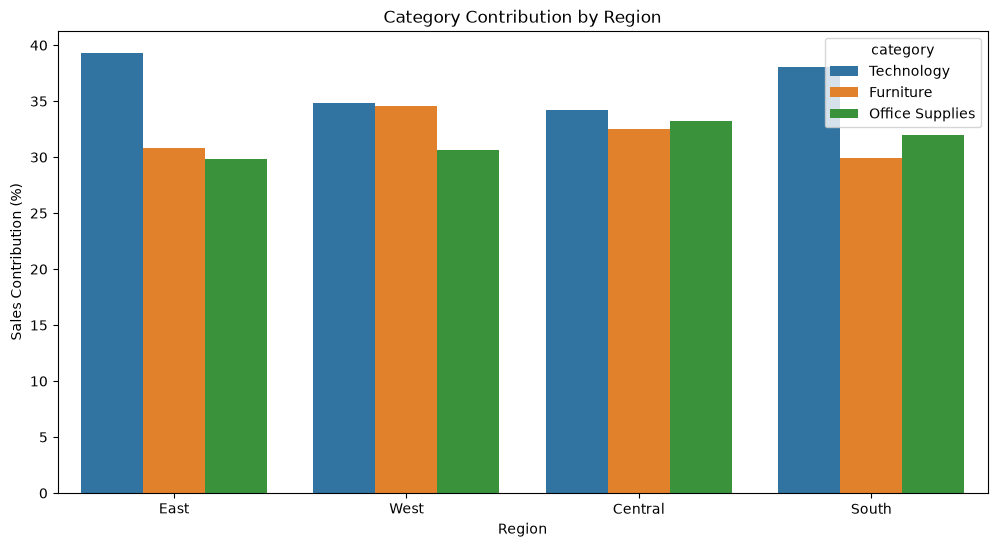

In [63]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_category_sales,
    x='region',
    y='sales_contribution_pct',
    hue='category'
)

plt.title('Category Contribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales Contribution (%)')

plt.show()

# 7. Extract Business Insight

In [64]:
# Display the highest-performing category in each region

for _, row in top_category_region.iterrows():
    print(
        f"{row['region']}: "
        f"{row['category']} "
        f"({row['sales']:,.2f})"
    )

Central: Technology (168,739.21)
East: Technology (263,116.53)
South: Technology (148,195.21)
West: Technology (247,404.93)


## 🗺️ Step 4.2 — State-Level Sales Performance

## 1. State Wise Sales

In [65]:
# State-wise Sales
state_sales = (
    df.groupby('state')['sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

state_sales.head(10)

,state,sales
0,California,446306.4635
1,New York,306361.1470
2,Texas,168572.5322
3,Washington,135206.8500
4,Pennsylvania,116276.6500
5,Florida,88436.5320
6,Illinois,79236.5170
7,Michigan,76136.0740
8,Ohio,75130.3500
9,Virginia,70636.7200


## Visualisaton

## 2. Top 10 States

In [66]:
# Top 10 States by Sales
top_10_states = state_sales.head(10)

top_10_states

,state,sales
0,California,446306.4635
1,New York,306361.1470
2,Texas,168572.5322
3,Washington,135206.8500
4,Pennsylvania,116276.6500
5,Florida,88436.5320
6,Illinois,79236.5170
7,Michigan,76136.0740
8,Ohio,75130.3500
9,Virginia,70636.7200


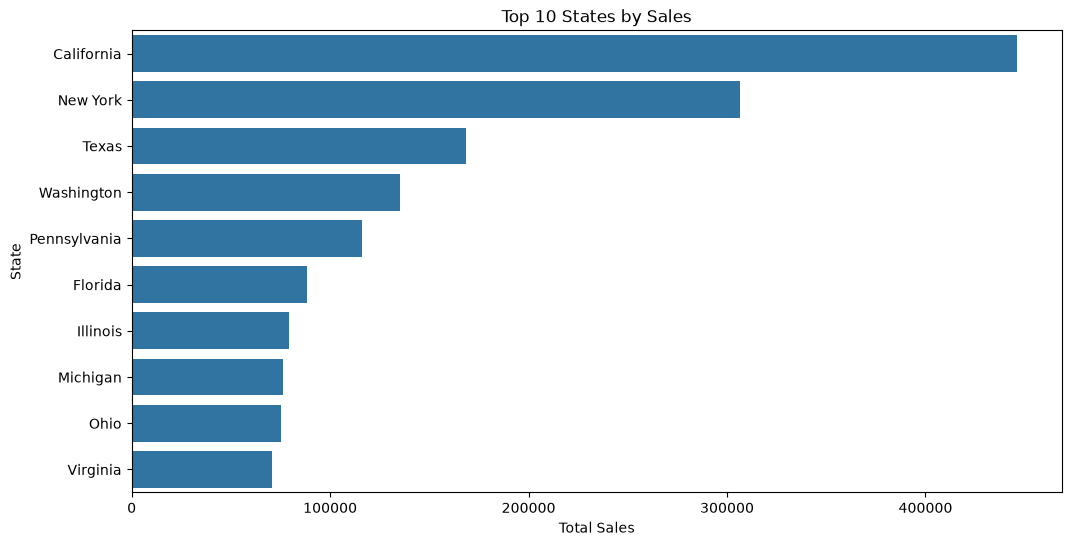

In [67]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_states,
    x='sales',
    y='state'
)

plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')

plt.show()

## 3. Botttom 10 States

In [68]:
# Bottom 10 States by Sales
bottom_10_states = state_sales.tail(10).sort_values(
    'sales',
    ascending=True
)

bottom_10_states

,state,sales
48,North Dakota,919.910
47,West Virginia,1209.824
46,Maine,1270.530
45,South Dakota,1315.560
44,Wyoming,1603.136
43,District of Columbia,2865.020
42,Kansas,2914.310
41,Idaho,4382.486
40,Iowa,4443.560
39,New Mexico,4783.522


## Visualisation

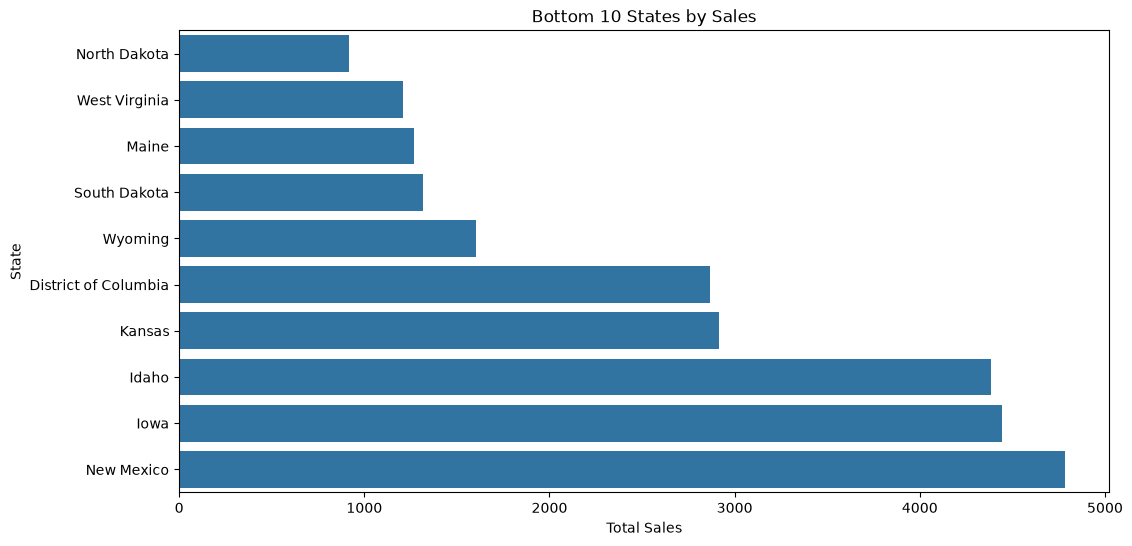

In [69]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=bottom_10_states,
    x='sales',
    y='state'
)

plt.title('Bottom 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')

plt.show()

## 4. State Sales Contribution

In [70]:
# Calculate State Sales Contribution %

total_sales = df['sales'].sum()

state_sales['sales_contribution_pct'] = (
    state_sales['sales'] / total_sales * 100
)

state_sales.head(10)

,state,sales,sales_contribution_pct
0,California,446306.4635,19.734654
1,New York,306361.1470,13.546591
2,Texas,168572.5322,7.453893
3,Washington,135206.8500,5.978539
4,Pennsylvania,116276.6500,5.141488
5,Florida,88436.5320,3.910462
6,Illinois,79236.5170,3.503658
7,Michigan,76136.0740,3.366564
8,Ohio,75130.3500,3.322093
9,Virginia,70636.7200,3.123395


## 5. City Level Sales

In [71]:
# City-wise Sales
city_sales = (
    df.groupby(['city', 'state'])['sales']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

city_sales.head(10)

,city,state,sales
0,New York City,New York,252462.5470
1,Los Angeles,California,173420.1810
2,Seattle,Washington,116106.3220
3,San Francisco,California,109041.1200
4,Philadelphia,Pennsylvania,108841.7490
5,Houston,Texas,63956.1428
6,Chicago,Illinois,47820.1330
7,San Diego,California,47521.0290
8,Detroit,Michigan,42446.9440
9,Jacksonville,Florida,39133.3280


## 6. Top 10 cities

In [72]:
top_10_cities = city_sales.head(10)

top_10_cities

,city,state,sales
0,New York City,New York,252462.5470
1,Los Angeles,California,173420.1810
2,Seattle,Washington,116106.3220
3,San Francisco,California,109041.1200
4,Philadelphia,Pennsylvania,108841.7490
5,Houston,Texas,63956.1428
6,Chicago,Illinois,47820.1330
7,San Diego,California,47521.0290
8,Detroit,Michigan,42446.9440
9,Jacksonville,Florida,39133.3280


## Visualisation

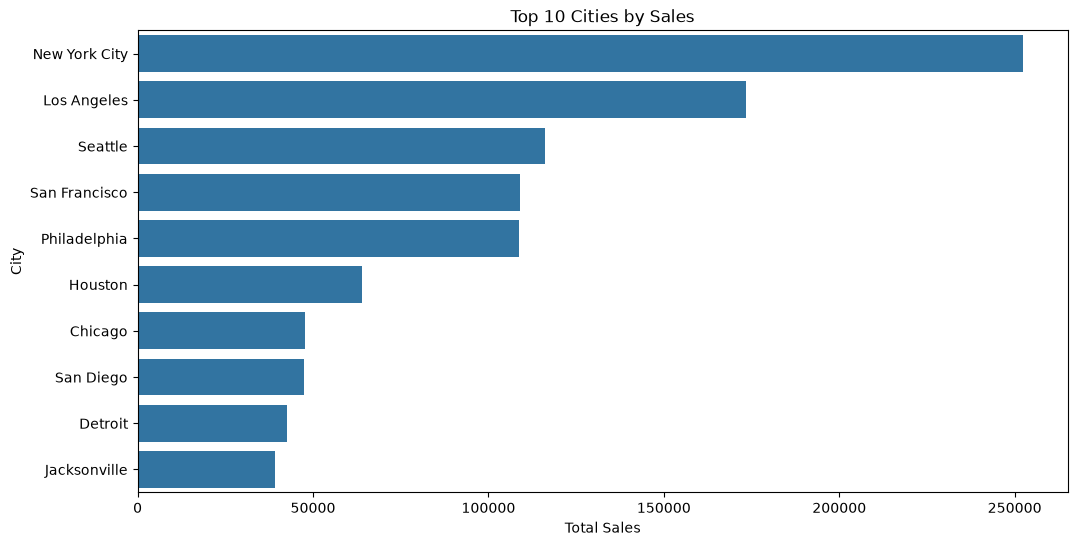

In [73]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_cities,
    x='sales',
    y='city'
)

plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')

plt.show()

## 7. Region → State Analysis

In [74]:
region_state_sales = (
    df.groupby(['region', 'state'])['sales']
      .sum()
      .reset_index()
      .sort_values(
          ['region', 'sales'],
          ascending=[True, False]
      )
)

region_state_sales.head(20)

,region,state,sales
11,Central,Texas,168572.5322
0,Central,Illinois,79236.5170
4,Central,Michigan,76136.0740
1,Central,Indiana,48718.4000
12,Central,Wisconsin,31173.4300
5,Central,Minnesota,29863.1500
6,Central,Missouri,22205.1500
9,Central,Oklahoma,19683.3900
7,Central,Nebraska,7464.9300
2,Central,Iowa,4443.5600


## 8. Create a Clean State Summary

In [75]:
state_summary = (
    df.groupby('state')
      .agg(
          total_sales=('sales', 'sum'),
          total_orders=('order_id', 'nunique'),
          total_customers=('customer_id', 'nunique')
      )
      .reset_index()
)

state_summary['sales_contribution_pct'] = (
    state_summary['total_sales'] / total_sales * 100
)

state_summary = state_summary.sort_values(
    'total_sales',
    ascending=False
)

state_summary.head(10)

,state,total_sales,total_orders,total_customers,sales_contribution_pct
3,California,446306.4635,1002,570,19.734654
30,New York,306361.1470,547,409,13.546591
41,Texas,168572.5322,480,367,7.453893
45,Washington,135206.8500,254,223,5.978539
36,Pennsylvania,116276.6500,285,255,5.141488
8,Florida,88436.5320,197,178,3.910462
11,Illinois,79236.5170,270,231,3.503658
20,Michigan,76136.0740,116,105,3.366564
33,Ohio,75130.3500,227,196,3.322093
44,Virginia,70636.7200,115,107,3.123395


In [76]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,year,month,month_number,quarter,year_quarter,year_month,shipping_days,order_total_sales,customer_total_sales,sales_category,shipping_category,profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,November,11,4,2017-Q4,2017-11,3,993.9000,1148.7800,Medium,Standard,26.19600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,November,11,4,2017-Q4,2017-11,3,993.9000,1148.7800,High,Standard,73.19400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,June,6,2,2017-Q2,2017-06,4,14.6200,1119.4830,Low,Standard,1.46200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,October,10,4,2016-Q4,2016-10,7,979.9455,2602.5755,High,Very Slow,95.75775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,2016,October,10,4,2016-Q4,2016-10,7,979.9455,2602.5755,Low,Very Slow,2.23680


## Connect to SQL

In [77]:
from sqlalchemy import create_engine

username = "postgres"
password = "8210"
host = "localhost"
port = "5432"
database = "sales_performance_analysis"

engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Load DataFrame into PostgreSQL
df.to_sql(
    "sales_data",
    engine,
    schema="public",
    if_exists="replace",
    index=False
)

print("✅ Data loaded successfully into PostgreSQL!")

✅ Data loaded successfully into PostgreSQL!
